In [25]:
import pandas as pd
import sys
import matplotlib.pyplot as plt
import matplotlib.pyplot as mpatches 
sys.path.append("/Users/emilieyu/endotehelial-masboss")

from src.paths import ABM_SIM_RES_DIR, REPORT_FIG_DIR, PROCESSED_DATA_DIR
from src.utils.file_utils import save_df_to_csv, load_csv_to_df
from src.visualisation.bar_plotter import plot_bar_metrics

cell_ss_df = load_csv_to_df(in_dir=ABM_SIM_RES_DIR, file_name="abm_cell_steady_state")
report_metric_cols = ['perturbation', 'ar', 'rho_balance', 'sf_squeeze', 'cortex_force_spread', 'sf_a', 'cortex_a_mean']
rho_cols = ['perturbation', 'ar', 'rhoa_mean', 'rhoc_mean']

>>> INFO: Loaded abm_cell_steady_state.csv from /Users/emilieyu/endotehelial-masboss/results/abm/sim


In [ ]:
rho_df = cell_ss_df[rho_cols].copy()

ar_wt = rho_df.loc[rho_df["perturbation"] == "WT", "ar",].iloc[0]
rhoa_wt = rho_df.loc[rho_df["perturbation"] == "WT", "rhoa_mean"].iloc[0]
rhoc_wt = rho_df.loc[rho_df["perturbation"] == "WT", "rhoc_mean"].iloc[0]

rho_df["ar_norm"] = rho_df["ar"] / ar_wt
rho_df["rhoa_norm"] = rho_df["rhoa_mean"] / rhoa_wt
rho_df["rhoc_norm"] = rho_df["rhoc_mean"] / rhoc_wt

# optional (recommended)
rho_df 

>>> INFO: Saved normalised_ar_and_rho.csv to /Users/emilieyu/endotehelial-masboss/data/processed


,perturbation,ar,rhoa_mean,rhoc_mean,ar_norm,rhoa_norm,rhoc_norm
0,WT,1.640,0.496,0.487,1.000000,1.000000,1.000000
1,DSP_KO,1.916,0.306,0.575,1.168293,0.616935,1.180698
2,TJP1_KO,1.462,0.582,0.308,0.891463,1.173387,0.632444
3,JCAD_KO,1.658,0.452,0.445,1.010976,0.911290,0.913758
4,DSP_JCAD_DKO,1.828,0.342,0.512,1.114634,0.689516,1.051335
5,TJP1_JCAD_DKO,1.540,0.512,0.342,0.939024,1.032258,0.702259


In [32]:
rho_norm_df = rho_df[["perturbation", "ar_norm", "rhoa_norm", "rhoc_norm"]].copy()
num_cols = rho_norm_df.select_dtypes(include="number").columns

pct_df = rho_norm_df.copy()
pct_df[num_cols] = (pct_df[num_cols] - 1) * 100
pct_df.round(2)

,perturbation,ar_norm,rhoa_norm,rhoc_norm
0,WT,0.00,0.00,0.00
1,DSP_KO,16.83,-38.31,18.07
2,TJP1_KO,-10.85,17.34,-36.76
3,JCAD_KO,1.10,-8.87,-8.62
4,DSP_JCAD_DKO,11.46,-31.05,5.13
5,TJP1_JCAD_DKO,-6.10,3.23,-29.77


## sim + exp combined

In [9]:
# Load
sim_df = load_csv_to_df(PROCESSED_DATA_DIR, "abm_sim_key_metrics")
exp_df = load_csv_to_df(PROCESSED_DATA_DIR, "exp_key_metrics")

# AR extraction
exp_ar = exp_df[["perturbation", "mean_ar", "std_ar"]].copy()
sim_ar = sim_df[["perturbation", "ar"]].copy()

exp_ar = exp_ar.rename(columns={"mean_ar": "exp_ar"})
sim_ar = sim_ar.rename(columns={"ar": "sim_ar"})

ar_df = exp_ar.merge(sim_ar, on="perturbation", how="inner")

>>> INFO: Loaded abm_sim_key_metrics.csv from /Users/emilieyu/endotehelial-masboss/data/processed
>>> INFO: Loaded exp_key_metrics.csv from /Users/emilieyu/endotehelial-masboss/data/processed


In [ ]:
# Normalise
wt_exp = ar_df.loc[ar_df["perturbation"] == "WT", "exp_ar"].iloc[0]
wt_sim = ar_df.loc[ar_df["perturbation"] == "WT", "sim_ar",].iloc[0]

ar_df["exp_ar_norm"] = ar_df["exp_ar"] / wt_exp
ar_df["std_ar_norm"] = ar_df["std_ar"] / wt_exp
ar_df["sim_ar_norm"] = ar_df["sim_ar"] / wt_sim


In [11]:
ar_norm_df = ar_df[["perturbation", "sim_ar_norm", "exp_ar_norm", "std_ar_norm"]].copy()

# Rename columns
ar_norm_df = ar_norm_df.rename(columns={
    "perturbation": "Perturbation",
    "sim_ar_norm": "Sim AR/WT",
    "exp_ar_norm": "Exp AR/WT",
}).round(3)

ar_norm_df

,Perturbation,Sim AR/WT,Exp AR/WT,std_ar_norm
0,WT,1.000,1.000,0.502
1,DSP_KO,1.168,1.304,0.799
2,TJP1_KO,0.891,0.624,0.322
3,JCAD_KO,1.011,1.006,0.578
4,DSP_JCAD_DKO,1.115,1.152,0.599
5,TJP1_JCAD_DKO,0.939,0.748,0.367


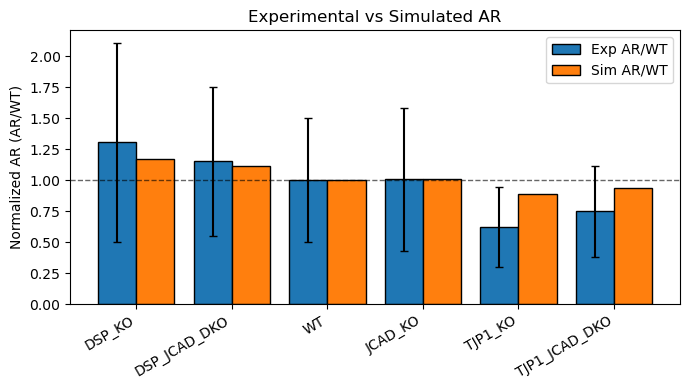

In [23]:
# Plotting
ORDER = ['DSP_KO', 'DSP_JCAD_DKO', 'WT', 'JCAD_KO', 'TJP1_KO', 'TJP1_JCAD_DKO']
plot_bar_metrics(
    df=ar_norm_df,
    x_col="Perturbation",
    y_cols=["Exp AR/WT", "Sim AR/WT"],
    order=ORDER,
    title="Experimental vs Simulated AR",
    ylabel="Normalized AR (AR/WT)",
    yerr_cols=['std_ar_norm', None],
    outdir=REPORT_FIG_DIR,
)